In [5]:
batch_size = 100
epochs = 5
learning_rate = 0.001
num_classes = 10


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transfroms

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(1000)
if device == 'cuda':
    torch.cuda.manual_seed_all(1000)
print(device + " is available")


cpu is available
cpu is available


In [9]:
train_set = torchvision.datasets.MNIST(
  root = './data/',
  train = True,
  download = True,
  transform = transfroms.Compose([
    transfroms.ToTensor()
  ])
)


In [10]:
test_set = torchvision.datasets.MNIST(
  root = './data/',
  train = False,
  download = True,
  transform = transfroms.Compose([
    transfroms.ToTensor()
  ])
)


In [11]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size)


In [12]:
examples = enumerate(train_set)
batch_idx, (example_data, example_targets) = next(examples)
example_data.shape

torch.Size([1, 28, 28])

In [13]:
torch.Size([1, 28, 28])

torch.Size([1, 28, 28])

In [14]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
    self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
    self.drop2D = nn.Dropout2d(p=0.25, inplace=False)
    self.mp = nn.MaxPool2d(2)
    self.fc1 = nn.Linear(320,100)
    self.fc2 = nn.Linear(100,10)
  def forward(self, x):
    x = F.relu(self.mp(self.conv1(x)))
    x = F.relu(self.mp(self.conv2(x)))
    x = self.drop2D(x)
    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = self.fc2(x)
    return F.log_softmax(x)

In [15]:
model = CNN().to(device)


In [16]:
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)


In [17]:
for epoch in range(epochs):
  avg_cost = 0
  for data, target in train_loader:
    data = data.to(device)
    target = target.to(device)
    optimizer.zero_grad()
    hypothesis = model(data)
    cost = criterion(hypothesis, target)
    cost.backward()
    optimizer.step()
    avg_cost += cost / len(train_loader)
  print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, avg_cost))

<ipython-input-14-6bfeea3c22cd>:17: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


[Epoch:    1] cost = 0.34330821
[Epoch:    2] cost = 0.122701079
[Epoch:    3] cost = 0.0970276743
[Epoch:    4] cost = 0.0808812678
[Epoch:    5] cost = 0.0727936625


In [18]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for data, target in test_loader:
    data = data.to(device)
    target = target.to(device)
    out = model(data)
    preds = torch.max(out.data, 1)[1]
    total += len(target)
    correct += (preds==target).sum().item()
  print('Test Accuracy: ', 100.*correct/total, '%')


<ipython-input-14-6bfeea3c22cd>:17: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


Test Accuracy:  98.56 %


In [19]:
import matplotlib.pyplot as plt

In [20]:
image_index = 1


In [21]:
print(data[image_index])


tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

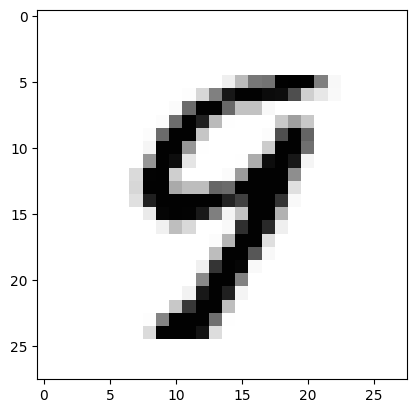

In [22]:
plt.imshow(data[image_index].reshape(28,28), cmap='Greys')

In [23]:
preds[image_index]

tensor(9)